# Human In the Loop

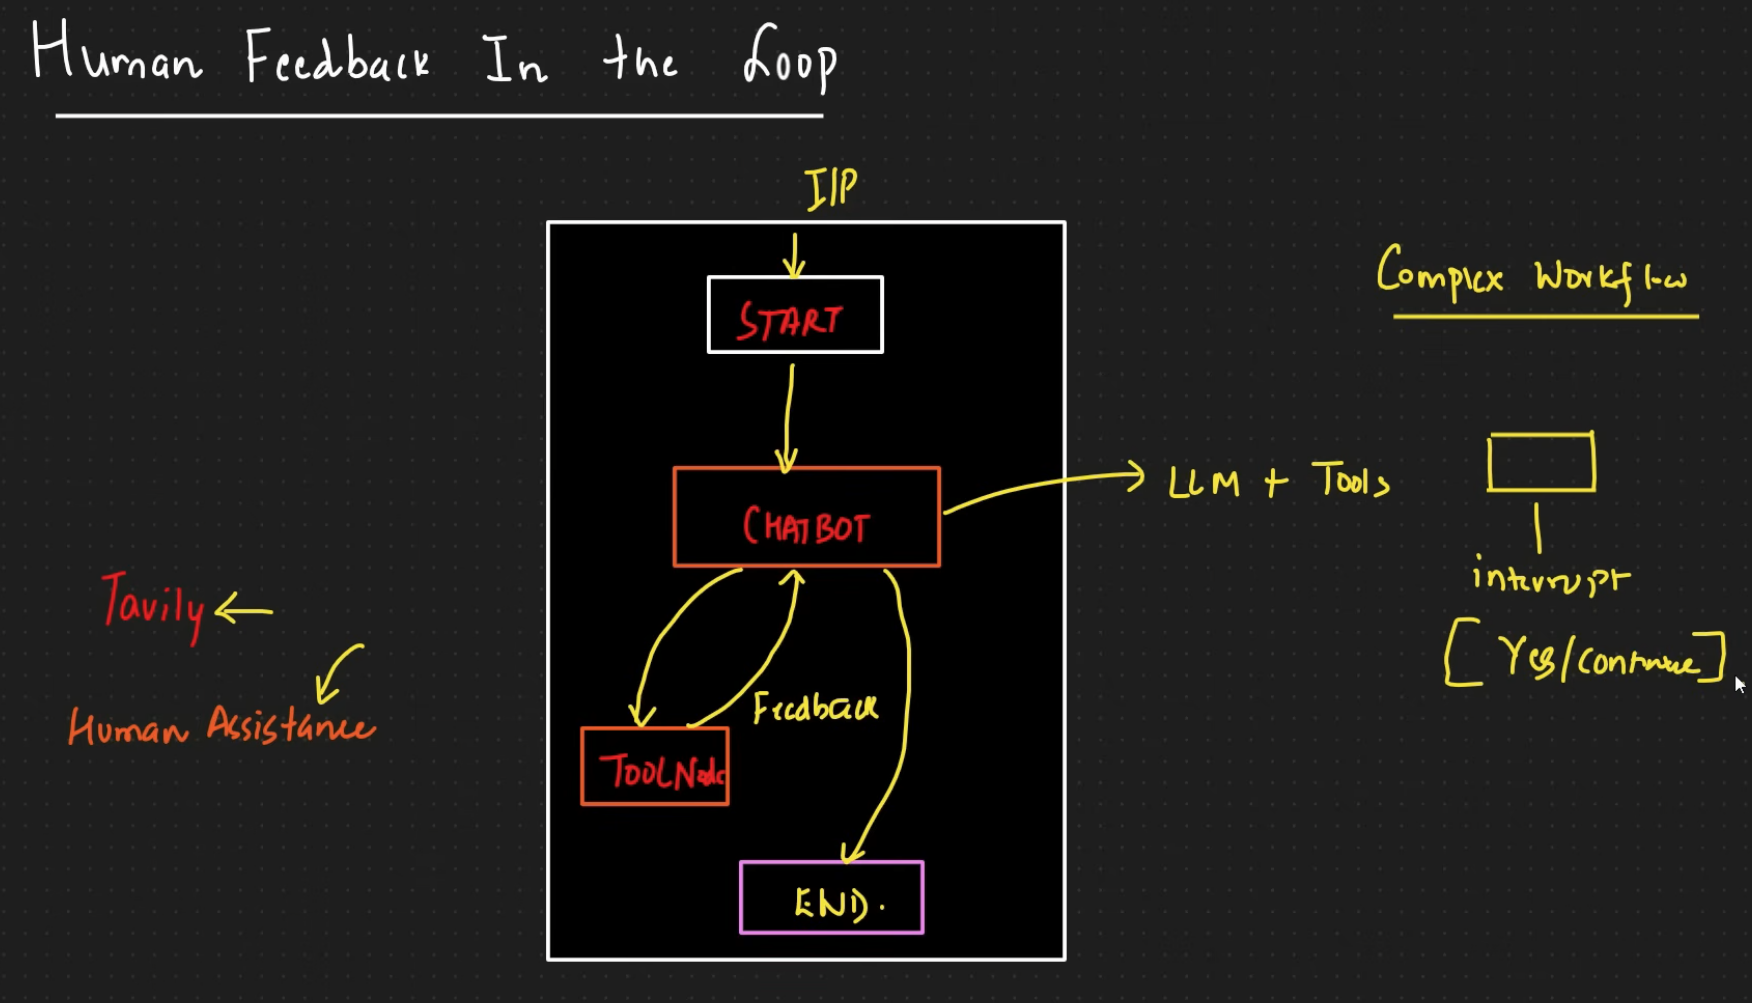

In [1]:
import os
from langchain.chat_models import init_chat_model
llm = init_chat_model("groq:llama-3.3-70b-versatile")

llm

/app/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.12'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x7fdb8a7f4bc0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7fdb89ebac30>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [ ]:
# # there are 2 ways to bind_tools
# # 1. llm.bind_tools(tools)
# # 2. create_agent(model=llm, tools=tools)

from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.types import Command, interrupt

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

@tool
def human_assistance(query: str) -> str:
    """Request assistance from a human."""
    human_response = interrupt({"query": query})
    return human_response["data"]

tool = TavilySearch(max_results=2)
tools = [tool, human_assistance]
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    message = llm_with_tools.invoke(state["messages"])
    # Because we will be interrupting during tool execution,
    # we disable parallel tool calling to avoid repeating any
    # tool invocations when we resume.
    
    return {"messages": [message]}

graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")




In [22]:
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

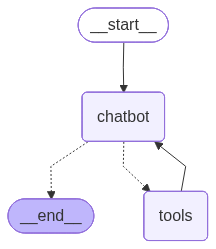

In [23]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [24]:
user_input = "I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?"
config = {"configurable": {"thread_id": "134fa"}}

events = graph.stream(
    {"messages": user_input},
    config,
    stream_mode="values",
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (cgjstqsjz)
 Call ID: cgjstqsjz
  Args:
    query: I need expert guidance and assistance for building an AI agent.
================================== Ai Message ==================================
Tool Calls:
  human_assistance (cgjstqsjz)
 Call ID: cgjstqsjz
  Args:
    query: I need expert guidance and assistance for building an AI agent.


In [25]:
# As the response from the llm needs human to interrupt and answer; so human is answering and helping llm
human_response = (
    "We, the experts are here to help! We'd recommend you check out Langgraph to build your agent."
    "It's much more reliable and extensible than simple autonomous agents."
)

human_command = Command(resume={"data": human_response})

events = graph.stream(
    human_command,
    config=config,
    stream_mode="values"
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (cgjstqsjz)
 Call ID: cgjstqsjz
  Args:
    query: I need expert guidance and assistance for building an AI agent.
================================= Tool Message =================================
Name: human_assistance

We, the experts are here to help! We'd recommend you check out Langgraph to build your agent.It's much more reliable and extensible than simple autonomous agents.
================================== Ai Message ==================================

I hope the guidance provided by the human assistance helps you with building your AI agent. If you need any more help or have further questions, feel free to ask!
